In [118]:
import os
import pandas as pd
import datetime as dt
from datetime import date
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import adfuller

In [119]:
TICKERS = {
    
    "Amazon": "AMZN",
    "Intel": "INTC",
    "AMD": "AMD",
    "General Electric": "GE",
}

In [120]:
def load_data(company_name, period="10y"):
    ticker = TICKERS[company_name]
    data = yf.download(ticker, period=period)
    data.reset_index(inplace=True)
    return  data

In [ ]:
company_name = "AMD"
data = load_data(company_name)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,GE,GE,GE,GE,GE
0,2016-04-15,132.267227,132.565601,131.840967,132.437728,5099722
1,2016-04-18,132.395004,132.949136,131.713000,131.713000,4397428
2,2016-04-19,132.778656,133.034414,132.181895,132.736027,4772603
3,2016-04-20,132.778656,133.631162,132.352396,132.991786,5540166
4,2016-04-21,132.054047,133.332812,131.499915,132.650807,8273744


In [122]:
data.shape

(2513, 6)

In [123]:
price = data["Close"]
price

Ticker,GE
0,132.267227
1,132.395004
2,132.778656
3,132.778656
4,132.054047
...,...
2508,308.059998
2509,313.019989
2510,308.350006
2511,311.899994


Text(0, 0.5, 'Closing Prices')

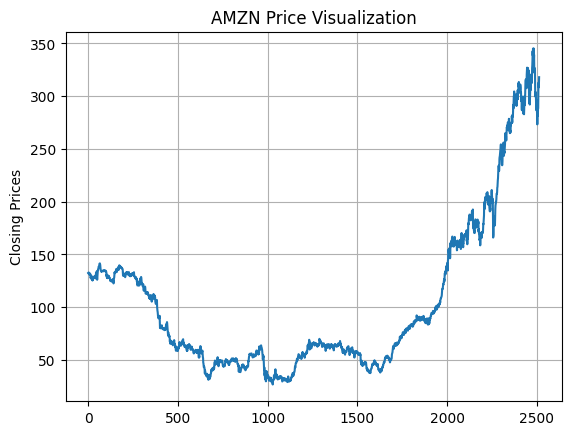

In [124]:
plt.title(f"{ticker} Price Visualization")
plt.plot(price)
plt.grid()
plt.ylabel('Closing Prices')

In [125]:
def test_stationarity(timeseries):
    '''
    Input: timeseries (dataframe): timeseries for which we want to study the stationarity
    '''
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(20).mean()
    rolstd = timeseries.rolling(20).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value',\
                                             '#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

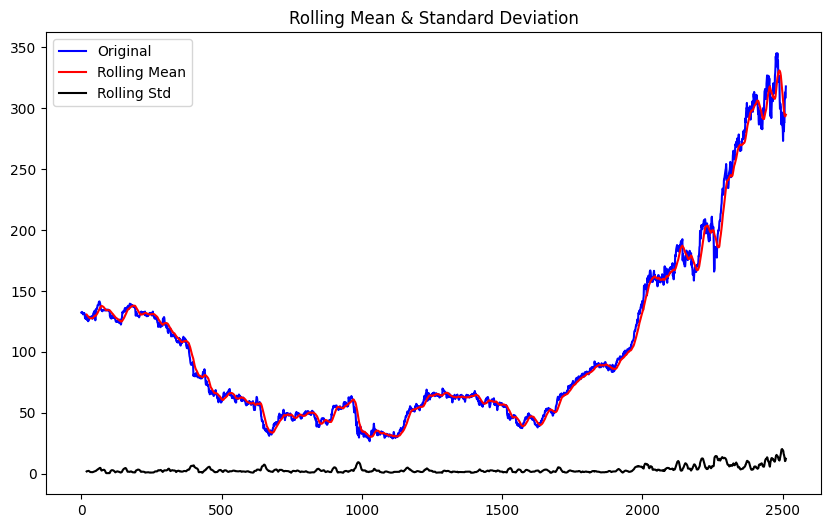

Results of Dickey-Fuller Test:
Test Statistic                    2.869269
p-value                           1.000000
#Lags Used                       26.000000
Number of Observations Used    2486.000000
Critical Value (1%)              -3.432983
Critical Value (5%)              -2.862703
Critical Value (10%)             -2.567389
dtype: float64


In [126]:
plt.figure(figsize = (10,6))
test_stationarity(data["Close"])

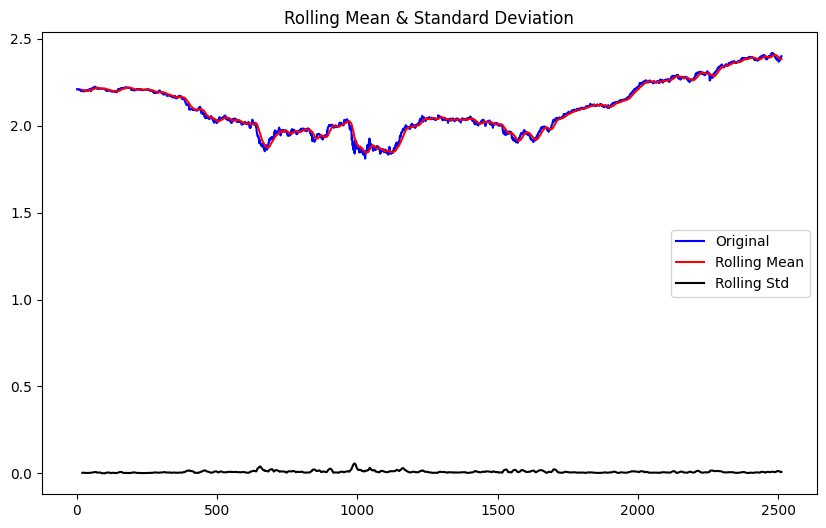

Results of Dickey-Fuller Test:
Test Statistic                   -0.313035
p-value                           0.923638
#Lags Used                       12.000000
Number of Observations Used    2500.000000
Critical Value (1%)              -3.432968
Critical Value (5%)              -2.862697
Critical Value (10%)             -2.567386
dtype: float64


In [127]:
data_log = np.log(data["Close"])
data_sqrt = np.sqrt(data_log)
plt.figure(figsize = (10,6))
test_stationarity(data_sqrt)

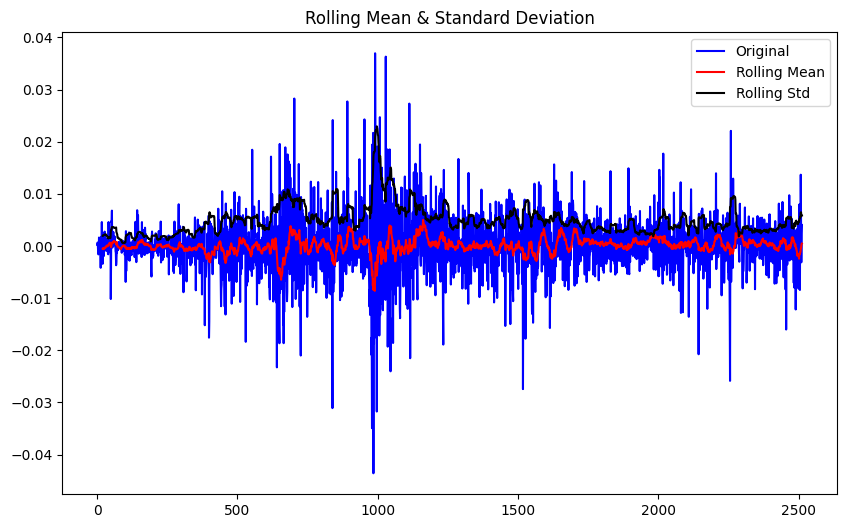

Results of Dickey-Fuller Test:
Test Statistic                -8.606052e+00
p-value                        6.668029e-14
#Lags Used                     2.700000e+01
Number of Observations Used    2.484000e+03
Critical Value (1%)           -3.432985e+00
Critical Value (5%)           -2.862704e+00
Critical Value (10%)          -2.567390e+00
dtype: float64


In [128]:
data_sqrt_diff = data_sqrt - data_sqrt.shift()
data_sqrt_diff.dropna(inplace=True)
plt.figure(figsize = (10,6))
test_stationarity(data_sqrt_diff)

In [129]:
# Preprocessing the data for LSTM model

def create_dataset(dataset, time_step=1):
    dataset = np.array(dataset)
    if dataset.ndim == 1:
        dataset = dataset.reshape(-1, 1)

    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]
        X.append(a)
        Y.append(dataset[i + time_step, 0])

    X = np.array(X)
    Y = np.array(Y)
    X = X.reshape(X.shape[0], X.shape[1], 1)
    return X, Y

In [130]:
time_step = 60

X_raw, y_raw = create_dataset(data_sqrt_diff.values, time_step=time_step)

train_size = int(len(X_raw) * 0.8)
X_train_raw, y_train_raw = X_raw[:train_size], y_raw[:train_size]
X_test_raw, y_test_raw = X_raw[train_size:], y_raw[train_size:]

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(X_train_raw.reshape(-1, 1))

X_train = scaler.transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape)
X_test = scaler.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape)

y_train = scaler.transform(y_train_raw.reshape(-1, 1)).reshape(-1)
y_test = scaler.transform(y_test_raw.reshape(-1, 1)).reshape(-1)

In [131]:
X_train.shape, y_train.shape   

((1960, 60, 1), (1960,))

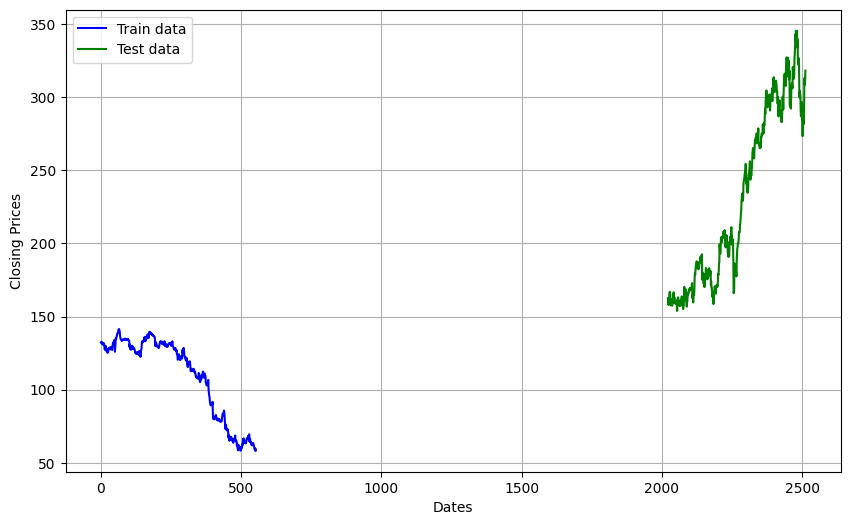

In [132]:
train_original = data["Close"].iloc[:-len(y_train)]
test_original = data["Close"].iloc[-len(y_test):]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.legend()

In [133]:
# LSTM Model Building
model = Sequential()
model.add(Input(shape=(X_train.shape[1], 1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

In [134]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [135]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=["MAE"])

In [136]:
ticker = TICKERS.get(company_name, "AMZN").replace(" ", "_")

In [ ]:
os.makedirs('models', exist_ok=True)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint(f'models/{ticker}_best_model.keras', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)

In [138]:
model.fit(X_train, y_train, epochs=25, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop, checkpoint, reduce_lr])

Epoch 1/25
60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - MAE: 0.1628 - loss: 0.0531

62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - MAE: 0.0891 - loss: 0.0190 - val_MAE: 0.0390 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 2/25
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - MAE: 0.0519 - loss: 0.0062

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - MAE: 0.0503 - loss: 0.0057 - val_MAE: 0.0384 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 3/25
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - MAE: 0.0505 - loss: 0.0055

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - MAE: 0.0510 - loss: 0.0057 - val_MAE: 0.0379 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 4/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - MAE: 0.0512 - loss: 0.0058 - val_MAE: 0.0384 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 5/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - MAE: 0.0527 - loss: 0.0060 - val_MAE: 0.0431 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 6/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - MAE: 0.0505 - loss: 0.0057 - val_MAE: 0.0384 - val_loss: 0.0030 - learning_rate: 2.0000e-04
Epoch 7/25
60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - MAE: 0.0491 - loss: 0.0054

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - MAE: 0.0502 - loss: 0.0056 - val_MAE: 0.0378 - val_loss: 0.0030 - learning_rate: 2.0000e-04
Epoch 8/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - MAE: 0.0503 - loss: 0.0057 - val_MAE: 0.0382 - val_loss: 0.0030 - learning_rate: 2.0000e-04
Epoch 9/25
60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - MAE: 0.0489 - loss: 0.0053

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - MAE: 0.0500 - loss: 0.0056 - val_MAE: 0.0378 - val_loss: 0.0030 - learning_rate: 1.0000e-04
Epoch 10/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - MAE: 0.0501 - loss: 0.0056 - val_MAE: 0.0382 - val_loss: 0.0030 - learning_rate: 1.0000e-04
Epoch 11/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - MAE: 0.0501 - loss: 0.0056 - val_MAE: 0.0382 - val_loss: 0.0030 - learning_rate: 1.0000e-04
Epoch 12/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - MAE: 0.0500 - loss: 0.0056 - val_MAE: 0.0378 - val_loss: 0.0030 - learning_rate: 1.0000e-04
Epoch 13/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - MAE: 0.0501 - loss: 0.0056 - val_MAE: 0.0384 - val_loss: 0.0030 - learning_rate: 1.0000e-04
Epoch 14/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - MAE: 0.0500 - loss: 0.0056 - val_MAE: 0.0383 - val_loss: 0.0030 - learning_rate: 1.0000e-04


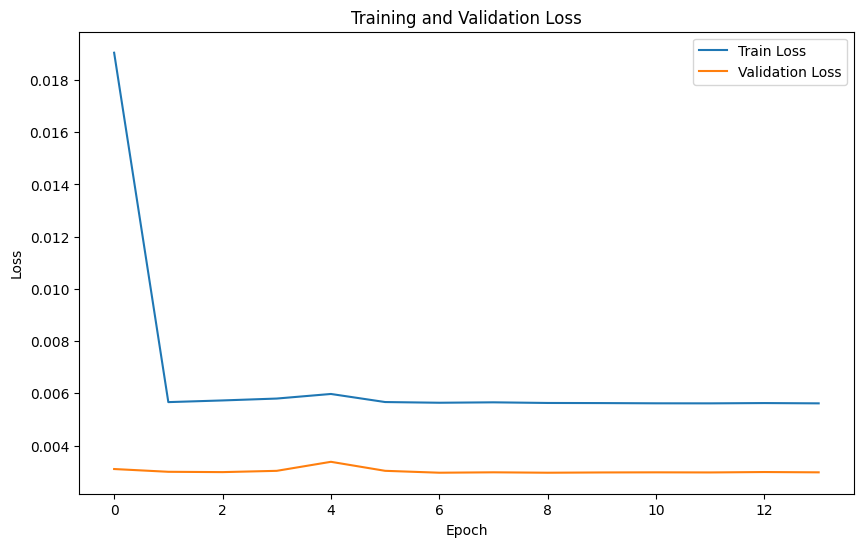

In [139]:
# PLot training and validation loss
plt.figure(figsize=(10,6))
plt.plot(model.history.history['loss'], label='Train Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

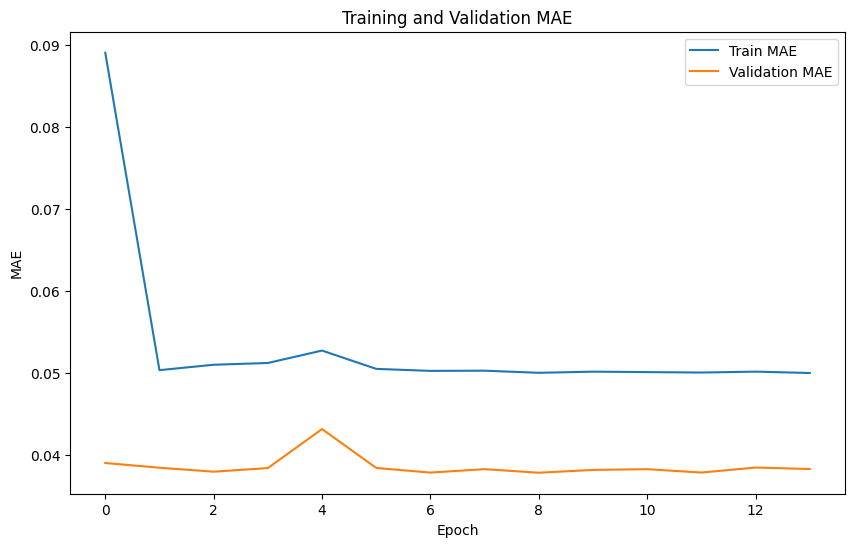

In [140]:
# PLotting the training and validation MAE
plt.figure(figsize=(10,6))
plt.plot(model.history.history['MAE'], label='Train MAE')
plt.plot(model.history.history['val_MAE'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training and Validation MAE')
plt.legend()
plt.show()

In [141]:
# Evaluate the model on the test data using the evaluate method
test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - MAE: 0.0378 - loss: 0.0030
Test Loss: 0.0029612011276185513
Test MAE: 0.03780889883637428


In [142]:
# Predicting the stock price using the trained model
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_scaled = scaler.inverse_transform(y_test.reshape(-1, 1))
# Calculate RMSE and MAE
rmse = np.sqrt(mean_squared_error(y_test_scaled, predictions))
mae = mean_absolute_error(y_test_scaled, predictions)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Root Mean Squared Error: 0.004383054976610356
Mean Absolute Error: 0.0030453484244955457


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


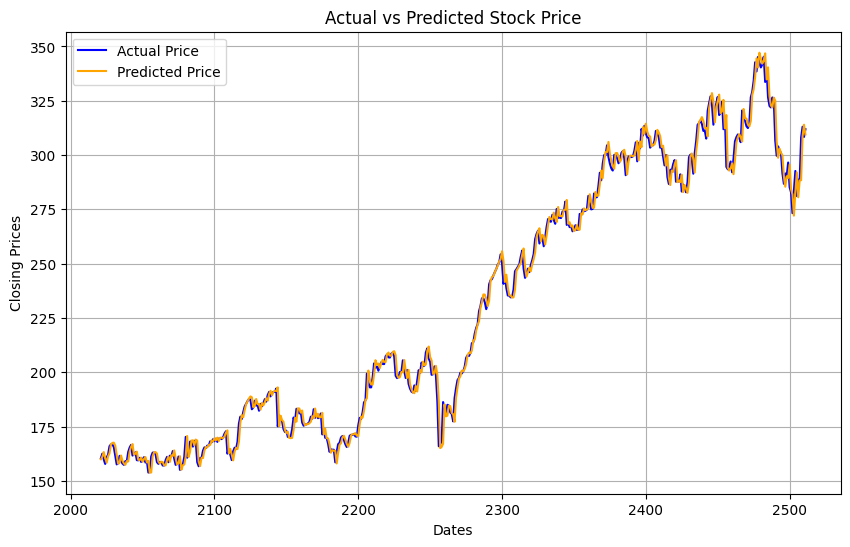

Price RMSE: 4.671582935814746


In [143]:
# Prediction on the test set in transformed space
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred).flatten()

# Reconstruct the original price from the transformed series
train_size = int(len(X_raw) * 0.8)
previous_positions = train_size + time_step
previous_sqrt_values = data_sqrt.values[previous_positions: previous_positions + len(y_test)]
actual_sqrt = data_sqrt.values[previous_positions + 1: previous_positions + 1 + len(y_test)]

predicted_sqrt = previous_sqrt_values + y_pred_inv
predicted_close = np.exp(predicted_sqrt ** 2)
actual_close = np.exp(actual_sqrt ** 2)

index_start = previous_positions + 1
test_index = data.index[index_start: index_start + len(y_test)]

# Prediction on the test set in transformed space
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred).flatten()

# Reconstruct the original price from the transformed series
train_size = int(len(X_raw) * 0.8)
previous_positions = train_size + time_step

data_sqrt_arr = np.asarray(data_sqrt).reshape(-1)
previous_sqrt_values = data_sqrt_arr[previous_positions: previous_positions + len(y_test)]
actual_sqrt = data_sqrt_arr[previous_positions + 1: previous_positions + 1 + len(y_test)]

predicted_sqrt = previous_sqrt_values + y_pred_inv
predicted_close = np.exp(predicted_sqrt ** 2)
actual_close = np.exp(actual_sqrt ** 2)

index_start = previous_positions + 1
test_index = data.index[index_start: index_start + len(y_test)]

pred_close_series = pd.Series(predicted_close.flatten(), index=test_index, name='Predicted')
actual_close_series = pd.Series(actual_close.flatten(), index=test_index, name='Actual')

plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(actual_close_series, 'b', label='Actual Price')
plt.plot(pred_close_series, 'orange', label='Predicted Price')
plt.title('Actual vs Predicted Stock Price')
plt.legend()
plt.show()

price_rmse = np.sqrt(mean_squared_error(actual_close, predicted_close))
print('Price RMSE:', price_rmse)

In [ ]:
model.save(f'models/{ticker}_final_model.keras')